# A4: Reasoning Strategies for Brand Recommendation Generation

**System:** Beacon — Social Media Brand Monitoring  
**Brand:** OpenAI  
**Owner:** Chieri Ishikawa  

---


## 1. Objective

This notebook compares four reasoning strategies for generating brand-response recommendations from OpenAI social media monitoring data, and identifies which is best suited to the task. The strategies are peers of the same type: each produces a complete recommendation set through a different reasoning structure.

| Strategy | Structure | Motivation |
|---|---|---|
| Chain-of-Thought (CoT) | One linear chain | Depth along a single path (Wei et al., 2022) |
| Self-Refine | One chain, then critique and revise | Depth via iterative improvement (Madaan et al., 2023) |
| Persona-diversified | Parallel expert perspectives, then synthesis | Breadth, domain-motivated |
| Tree-of-Thought (ToT) | Parallel branches, evaluated, then synthesis | Breadth, search-motivated (Yao et al., 2023) |

**Question under test:** Which structure produces the most actionable, specific, and evidence-grounded recommendations for this use case, and is any advantage large enough to justify its cost?

**Evaluation principle:** This is a fair comparison, not a search for a predetermined winner. The primary metric is forced pairwise preference, which resists rubric saturation on strong models. The verdict cell names the best technique from the computed numbers.

**Scope:** Standalone justification notebook. All inference runs locally via Ollama. The single export function is the integration surface extracted to `shared/recommendations.py`.


## 2. Setup

In [1]:
!pip install openai pandas numpy scipy matplotlib tqdm requests -q

In [2]:
import os
import re
import json
import time
import random
import requests
from pathlib import Path
from typing import Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, binomtest
from tqdm.auto import tqdm

# Ollama configuration
OLLAMA_BASE_URL = "http://localhost:11434/v1"
MODEL           = "qwen2.5:7b"
JUDGE_MODEL     = "llama3.2:3b"   
WEAK_MODEL      = "qwen2.5:1.5b"  
OLLAMA_NUM_CTX  = 8192
REQUEST_TIMEOUT = 120

SEED = 42
TEMP_DETERMINISTIC = 0.2
TEMP_DIVERSE       = 0.7

TOT_BRANCHES = 3
PERSONAS     = ["a crisis communications director",
                "a product marketing lead",
                "a community relations manager"]
N_MAIN       = 12
N_ABLATION   = 6
QUICK_TEST   = False

PRICING = {}

random.seed(SEED)
np.random.seed(SEED)
print(f"Generator/Judge: {MODEL}  |  Weak: {WEAK_MODEL}  |  num_ctx: {OLLAMA_NUM_CTX}")
print(f"Scenarios: main={N_MAIN}, ablation={N_ABLATION}  |  ToT branches: {TOT_BRANCHES}")

Generator/Judge: qwen2.5:7b  |  Weak: qwen2.5:1.5b  |  num_ctx: 8192
Scenarios: main=12, ablation=6  |  ToT branches: 3


c:\Users\jobpa\miniconda3\envs\comp8430\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Confirm Ollama is running and required models are pulled.
REQUIRED_MODELS = [MODEL, WEAK_MODEL]

try:
    resp = requests.get("http://localhost:11434/api/tags", timeout=5)
    resp.raise_for_status()
    available = [m["name"] for m in resp.json().get("models", [])]
    print("Ollama is running.")
    print("Models available:", available)
    missing = []
    for m in REQUIRED_MODELS:
        base = m.split(":")[0]
        if not any(base in a for a in available):
            missing.append(m)
    if missing:
        for m in missing:
            print(f"  WARNING: '{m}' not found locally. Run:  ollama pull {m}")
        raise RuntimeError(f"Missing models: {missing}. Pull them, then re-run this cell.")
    else:
        print("All required models are available.")
except requests.ConnectionError:
    raise RuntimeError(
        "Cannot connect to Ollama. Start it first:  ollama serve\n"
        "Then re-run this cell.")

Ollama is running.
Models available: ['qwen2.5:7b', 'llama3.2:3b', 'qwen2.5:1.5b']
All required models are available.


In [4]:
# Client initialisation: OpenAI-compatible Ollama endpoint
from openai import OpenAI, APITimeoutError, APIConnectionError
client = OpenAI(api_key="ollama", base_url=OLLAMA_BASE_URL)
print("Ollama client connected.")

Ollama client connected.


### 2.1 Unit of analysis: brand-state scenarios

A recommendation set is produced from a synthesised brand state, not a single post, so the experimental instance is a brand-state slice. Scenarios are stratified by crisis level (red, amber, green) and difficulty to test whether any method's advantage is conditional on case difficulty. All scenarios are constructed and flagged with `is_constructed = True`.


In [5]:
def S(sid, topic, pos, neu, neg, neg_d, pos_d, crisis, evidence):
    return {"scenario_id": sid, "topic": topic,
            "sentiment": {"positive": pos, "neutral": neu, "negative": neg},
            "negative_drivers": neg_d, "positive_drivers": pos_d,
            "crisis_level": crisis, "evidence": evidence, "is_constructed": True}

CONSTRUCTED_SCENARIOS = [
    S("S01_pricing_backlash", "Subscription pricing", .12, .23, .65,
      ["Plus price increase", "perceived value drop", "usage caps"],
      ["some defend pricing vs compute cost"], "red",
      [{"post_id":"c001","excerpt":"Paying more for fewer messages, not worth it anymore.","score":812},
       {"post_id":"c002","excerpt":"Price hike with tighter caps feels like a downgrade.","score":540}]),
    S("S05_leadership_controversy", "Leadership and governance", .16, .34, .50,
      ["governance uncertainty", "mixed messaging"], ["confidence in research direction"], "red",
      [{"post_id":"c006","excerpt":"Hard to plan a business when governance keeps shifting.","score":905}]),
    S("S06_outage", "Service outage", .08, .22, .70,
      ["multi-hour downtime", "status page lag"], ["fast recovery acknowledged by some"], "red",
      [{"post_id":"c007","excerpt":"Down three hours during our launch, status page said all green.","score":1120}]),
    S("S11_breach_rumour", "Security incident rumour", .06, .24, .70,
      ["unverified breach claims", "panic in threads"], ["official channel silent so far"], "red",
      [{"post_id":"c012","excerpt":"Screenshots claim a breach, no official word, people are scared.","score":1340}]),
    S("S12_deprecation_shock", "Sudden model deprecation", .10, .20, .70,
      ["model retired with short notice", "broken production apps"], ["newer model is better"], "red",
      [{"post_id":"c013","excerpt":"They killed the model our product depends on with two weeks notice.","score":980}]),
    S("S13_billing_error", "Mass billing error", .07, .18, .75,
      ["double charges", "slow refunds", "support backlog"], [], "red",
      [{"post_id":"c014","excerpt":"Charged twice and support has not replied in five days.","score":670}]),
    S("S03_api_rate_limits", "API rate limits", .18, .27, .55,
      ["tier limits", "unclear quota errors", "outages for small devs"], ["enterprise reliability"], "amber",
      [{"post_id":"c004","excerpt":"429s in production with no warning, docs do not explain tier math.","score":410}]),
    S("S04_safety_policy", "Safety and policy", .20, .30, .50,
      ["over-refusal", "opaque policy changes"], ["guardrails appreciated"], "amber",
      [{"post_id":"c005","excerpt":"Refuses benign requests now, policy shifts with no changelog.","score":289}]),
    S("S08_privacy", "Data privacy", .14, .31, .55,
      ["training data concerns", "retention questions"], ["enterprise data controls"], "amber",
      [{"post_id":"c009","excerpt":"Unclear whether my prompts train the model, toggle is buried.","score":463}]),
    S("S10_mixed_ambiguous", "General sentiment, ambiguous", .34, .34, .32,
      ["fatigue with hype", "inconsistent quality"], ["genuine utility", "habitual daily use"], "amber",
      [{"post_id":"c011","excerpt":"Love it and tired of the hype at once, quality varies by day.","score":521}]),
    S("S02_model_praise", "New model capability", .78, .15, .07,
      ["occasional latency"], ["reasoning quality", "coding help", "speed"], "green",
      [{"post_id":"c003","excerpt":"The new model one-shotted a refactor I struggled with for hours.","score":1340}]),
    S("S07_competitor_compare", "Competitor comparison", .30, .40, .30,
      ["rivals cheaper", "context window envy"], ["ecosystem maturity", "tooling"], "green",
      [{"post_id":"c008","excerpt":"Moved some workloads for price, kept OpenAI for tooling.","score":376}]),
    S("S09_developer_experience", "Developer experience", .45, .33, .22,
      ["SDK breaking changes", "sparse migration notes"], ["function calling", "structured outputs"], "green",
      [{"post_id":"c010","excerpt":"Structured outputs are great but the SDK bump broke our pipeline.","score":298}]),
    S("S20_education_use", "Education and learning", .62, .28, .10,
      ["citation reliability"], ["tutoring value", "accessibility"], "green",
      [{"post_id":"c021","excerpt":"It has become my default study partner, explains things clearly.","score":540}]),
    S("S21_accessibility_win", "Accessibility", .70, .22, .08,
      ["voice latency"], ["voice mode", "screen-reader friendly"], "green",
      [{"post_id":"c022","excerpt":"Voice mode is a genuine accessibility upgrade for me.","score":610}]),
    S("S22_community_tooling", "Community tooling", .58, .30, .12,
      ["fragmented libraries"], ["strong open-source community"], "green",
      [{"post_id":"c023","excerpt":"The community libraries around the API are thriving.","score":280}]),
]

def load_scenarios():
    try:
        topics = json.loads((Path("data/outputs") / "topics.json").read_text())
        if len(topics) >= 12:
            raise NotImplementedError
        raise FileNotFoundError
    except Exception:
        print("Using CONSTRUCTED scenarios (labelled is_constructed=True).")
        return CONSTRUCTED_SCENARIOS

SCENARIOS = load_scenarios()
if QUICK_TEST:
    N_MAIN, N_ABLATION = 3, 0
    print("QUICK_TEST on: 3-scenario run for pipeline verification only.")
MAIN_SET     = SCENARIOS[:N_MAIN]
ABLATION_SET = SCENARIOS[:N_ABLATION]
print(f"{len(SCENARIOS)} scenarios available. "
      f"Crisis mix: {pd.Series([s['crisis_level'] for s in SCENARIOS]).value_counts().to_dict()}")
print(f"Running {len(MAIN_SET)} main + {len(ABLATION_SET)} ablation scenarios.")

Using CONSTRUCTED scenarios (labelled is_constructed=True).
16 scenarios available. Crisis mix: {'red': 6, 'green': 6, 'amber': 4}
Running 12 main + 6 ablation scenarios.


## 3. Implementation

Each method consumes a brand state and returns a structured recommendation set with a metadata record of calls and tokens.

| Method | Calls per scenario | Mechanism |
|---|---|---|
| CoT | 1 | One reasoning chain, then recommend |
| Self-Refine | 3 | Draft, self-critique, revise |
| Persona | len(PERSONAS) + 1 | One set per expert persona, then synthesise |
| ToT | TOT_BRANCHES + 2 | Generate branches, evaluate each, synthesise the best |

All calls use the same locally-loaded model so there is no reload thrash between generation and judging.


In [6]:
def state_to_text(state: dict) -> str:
    s = state["sentiment"]
    ev = "\n".join(f'  - [{e["post_id"]}] "{e["excerpt"]}" (score {e["score"]})'
                   for e in state["evidence"])
    return (f'Topic: {state["topic"]}\nCrisis level: {state["crisis_level"]}\n'
            f'Sentiment: positive {s["positive"]:.0%}, neutral {s["neutral"]:.0%}, '
            f'negative {s["negative"]:.0%}\n'
            f'Negative drivers: {", ".join(state["negative_drivers"]) or "none"}\n'
            f'Positive drivers: {", ".join(state["positive_drivers"]) or "none"}\n'
            f'Supporting evidence posts:\n{ev}')

def _strip_fences(t: str) -> str:
    return re.sub(r"^```(?:json)?|```$", "", t.strip(), flags=re.MULTILINE).strip()

def parse_json(text: str, default):
    try:
        return json.loads(_strip_fences(text))
    except Exception:
        m = re.search(r"(\[.*\]|\{.*\})", _strip_fences(text), flags=re.DOTALL)
        if m:
            try:
                return json.loads(m.group(1))
            except Exception:
                return default
        return default

def chat(prompt: str, temperature: float, model: str = MODEL, _max_retries: int = 4):
    """One Ollama call with timeout and retry on transient failures.
    No rate-limit handling is needed for local inference.
    """
    last_error = None
    for attempt in range(_max_retries):
        try:
            resp = client.chat.completions.create(
                model=model,
                temperature=temperature,
                timeout=REQUEST_TIMEOUT,
                messages=[{"role": "user", "content": prompt}],
                extra_body={"options": {"num_ctx": OLLAMA_NUM_CTX}},
            )
            break
        except APITimeoutError as e:
            last_error = e
            wait = 10 * (attempt + 1)
            print(f"  Timeout on attempt {attempt+1}, retrying in {wait}s...")
            time.sleep(wait)
        except APIConnectionError:
            raise RuntimeError("Lost connection to Ollama. Is 'ollama serve' still running?")
    else:
        raise RuntimeError(f"Failed after {_max_retries} attempts. Last error: {last_error}")
    u = resp.usage
    usage = {"calls": 1,
             "in": getattr(u, "prompt_tokens", 0) or 0,
             "out": getattr(u, "completion_tokens", 0) or 0}
    return resp.choices[0].message.content, usage

def merge_usage(*usages):
    out = {"calls": 0, "in": 0, "out": 0}
    for u in usages:
        for k in out:
            out[k] += u[k]
    return out

def cost_usd(meta, model=MODEL):
    return 0.0   # local inference is free

REC_SCHEMA = ('Return ONLY a JSON array of 4 to 6 objects, no markdown and no prose. '
              'Each object has: "action" (a concrete recommendation), "rationale" '
              '(why, tied to the state), "evidence" (which driver or post_id supports '
              'it), "priority" (one of "high", "medium", "low").')

In [7]:
def cot_recommend(state, model=MODEL):
    """Single linear reasoning chain, then recommend."""
    prompt = (f"You advise OpenAI's brand team. Reason step by step before recommending.\n\n"
              f"{state_to_text(state)}\n\n"
              f"Step 1: Identify the core risk or opportunity.\n"
              f"Step 2: Identify affected stakeholders.\n"
              f"Step 3: Derive responses that address the drivers, grounded in the evidence.\n\n"
              f"After reasoning, output the recommendations. {REC_SCHEMA}")
    text, usage = chat(prompt, TEMP_DETERMINISTIC, model)
    return {"recommendations": parse_json(text, []), "_meta": usage}

def self_refine_recommend(state, model=MODEL):
    """Draft via CoT, self-critique, then revise (Madaan et al., 2023)."""
    draft = cot_recommend(state, model)
    recs  = draft["recommendations"]
    crit  = (f"Critically review the recommendation set below for this brand state. "
             f"Identify concrete weaknesses: coverage gaps against the drivers, "
             f"unsupported claims, vague or generic actions, redundancy. Be specific.\n\n"
             f"State:\n{state_to_text(state)}\n\nSet (JSON):\n{json.dumps(recs)[:4000]}")
    crit_text, u_crit = chat(crit, TEMP_DETERMINISTIC, model)
    rev   = (f"Revise the recommendation set to fix every weakness in the critique. "
             f"Keep what is strong, make vague actions concrete, remove redundancy.\n\n"
             f"State:\n{state_to_text(state)}\n\nOriginal (JSON):\n{json.dumps(recs)[:3000]}\n\n"
             f"Critique:\n{crit_text[:2000]}\n\n{REC_SCHEMA}")
    rev_text, u_rev = chat(rev, TEMP_DETERMINISTIC, model)
    return {"recommendations": parse_json(rev_text, recs),
            "_meta": merge_usage(draft["_meta"], u_crit, u_rev)}

def persona_recommend(state, personas=PERSONAS, model=MODEL):
    """One recommendation set per expert persona, then synthesise."""
    sets, usages = [], []
    for persona in personas:
        p = (f"You are {persona} advising OpenAI's brand team. From your professional "
             f"perspective specifically, recommend brand responses for this state.\n\n"
             f"{state_to_text(state)}\n\n{REC_SCHEMA}")
        t, u = chat(p, TEMP_DETERMINISTIC, model)
        sets.append(parse_json(t, [])); usages.append(u)
    syn = (f"Expert advisors ({', '.join(personas)}) each proposed recommendations. "
           f"Synthesise one coherent set integrating their complementary views, "
           f"removing redundancy.\n\nState:\n{state_to_text(state)}\n\n"
           f"Advisor sets (JSON):\n{json.dumps(sets)[:5000]}\n\n{REC_SCHEMA}")
    st, us = chat(syn, TEMP_DETERMINISTIC, model)
    return {"recommendations": parse_json(st, []), "_meta": merge_usage(*usages, us)}

def tot_recommend(state, k=TOT_BRANCHES, model=MODEL):
    """Generate candidate strategies, evaluate each, synthesise the best."""
    gen = (f"You advise OpenAI's brand team. Propose {k} DISTINCT candidate response "
           f"strategies differing in approach (for example reactive crisis control "
           f"versus proactive narrative building).\n\n{state_to_text(state)}\n\n"
           f'Return ONLY a JSON array of {k} objects, each with "strategy_name", '
           f'"approach" (2 to 3 sentences), and "actions" (3 to 5 concrete actions).')
    gen_text, u_gen = chat(gen, TEMP_DIVERSE, model)
    branches = parse_json(gen_text, [])
    if not isinstance(branches, list) or not branches:
        branches = [{"strategy_name": "fallback", "approach": gen_text, "actions": []}]
    scored, eval_usages = [], []
    for b in branches:
        ev = (f"Score this strategy 1 to 5 on: impact, feasibility, evidence_fit.\n\n"
              f"State:\n{state_to_text(state)}\n\nStrategy:\n{json.dumps(b)}\n\n"
              f'Return ONLY: {{"impact": int, "feasibility": int, "evidence_fit": int}}.')
        et, eu = chat(ev, TEMP_DETERMINISTIC, model)
        sc = parse_json(et, {"impact":3,"feasibility":3,"evidence_fit":3})
        sc["total"] = sc.get("impact",3)+sc.get("feasibility",3)+sc.get("evidence_fit",3)
        scored.append({"branch": b, "score": sc}); eval_usages.append(eu)
    scored.sort(key=lambda x: x["score"]["total"], reverse=True)
    syn = (f"From the highest-scoring strategies below, synthesise one coherent recommendation "
           f"set. Prefer the strongest but fold in complementary actions without redundancy.\n\n"
           f"State:\n{state_to_text(state)}\n\n"
           f"Top strategies (JSON):\n{json.dumps(scored[:max(1,k-1)])[:5000]}\n\n{REC_SCHEMA}")
    syn_text, u_syn = chat(syn, TEMP_DETERMINISTIC, model)
    return {"recommendations": parse_json(syn_text, []), "branches": scored,
            "_meta": merge_usage(u_gen, *eval_usages, u_syn)}

METHODS = {"CoT": cot_recommend, "Self-Refine": self_refine_recommend,
           "Persona": persona_recommend, "ToT": tot_recommend}
print("Recommendation methods defined.")

Recommendation methods defined.


In [8]:
RUBRIC = ["actionability", "specificity", "evidence_groundedness", "coverage", "non_redundancy"]

ANCHORS = (
    "Score each criterion from 1 to 10 using these anchors:\n"
    "  1-2: generic, no link to evidence, not executable.\n"
    "  3-4: vague, partially relevant, weak grounding.\n"
    "  5-6: solid and mostly actionable, some gaps.\n"
    "  7-8: specific, evidence-linked, clearly actionable.\n"
    "  9-10: exceptional, every action concrete, grounded, comprehensive, non-redundant.\n"
    "Be discriminating. Most sets should fall between 4 and 7. Do not cluster at the top."
)

def judge_pointwise(state, recommendations):
    prompt = (f"You are a critical, impartial evaluator of brand recommendations.\n{ANCHORS}\n\n"
              f"Criteria: actionability, specificity, evidence_groundedness, coverage of the "
              f"main risks and opportunities, non_redundancy.\n"
              f"Also count n_unsupported (claims not supported by the state) and n_total.\n\n"
              f"State:\n{state_to_text(state)}\n\n"
              f"Recommendations (JSON):\n{json.dumps(recommendations)[:5000]}\n\n"
              f'Return ONLY a JSON object with integer keys {RUBRIC} '
              f'plus "n_unsupported" and "n_total".')
    text, _ = chat(prompt, TEMP_DETERMINISTIC, JUDGE_MODEL)
    d = parse_json(text, {k:5 for k in RUBRIC} | {"n_unsupported":0,"n_total":1})
    n_total = max(1, d.get("n_total", len(recommendations) or 1))
    d["faithfulness"] = (n_total - d.get("n_unsupported", 0)) / n_total
    d["overall"] = float(np.mean([d.get(k, 5) for k in RUBRIC]))
    return d

def judge_pairwise(state, rec_a, rec_b):
    """Forced choice between two recommendation sets. Caller randomises slot order."""
    prompt = (f"Compare two recommendation sets for the same brand state and decide which "
              f"better serves the brand team overall, weighing actionability, evidence "
              f"grounding, and coverage. Avoid a tie unless truly indistinguishable.\n\n"
              f"State:\n{state_to_text(state)}\n\n"
              f"Set A (JSON):\n{json.dumps(rec_a)[:3500]}\n\n"
              f"Set B (JSON):\n{json.dumps(rec_b)[:3500]}\n\n"
              f'Return ONLY: {{"winner": "A" | "B" | "tie", "reason": str}}.')
    text, _ = chat(prompt, TEMP_DETERMINISTIC, JUDGE_MODEL)
    return parse_json(text, {"winner":"tie"}).get("winner", "tie")

print("Judges defined.")

Judges defined.


## 4. Results

Each method is run across all scenarios and scored on the anchored pointwise rubric. ToT is compared head to head against each peer under forced pairwise judging with randomised slot assignment to control position bias.

In [9]:
def run_main(scenarios):
    rows, raw, pairwise = [], {}, []
    opponents = ["CoT", "Self-Refine", "Persona"]
    for state in tqdm(scenarios, desc="main"):
        sid = state["scenario_id"]; raw[sid] = {}; recs = {}
        for name, fn in METHODS.items():
            out = fn(state); recs[name] = out["recommendations"]
            j = judge_pointwise(state, out["recommendations"])
            raw[sid][name] = {"recommendations": out["recommendations"],
                              "judge": j, "meta": out["_meta"]}
            rows.append({
                "scenario_id": sid, "crisis_level": state["crisis_level"], "method": name,
                **{k: j.get(k) for k in RUBRIC},
                "overall": j["overall"], "faithfulness": j["faithfulness"],
                "calls": out["_meta"]["calls"],
                "tokens": out["_meta"]["in"] + out["_meta"]["out"],
            })
        for opp in opponents:
            flip = random.random() < 0.5
            a, b = (recs["ToT"], recs[opp]) if flip else (recs[opp], recs["ToT"])
            w = judge_pairwise(state, a, b)
            winner = "tie" if w == "tie" else ("ToT" if (w == "A") == flip else opp)
            pairwise.append({"scenario_id": sid, "opponent": opp, "winner": winner})
    return {"rows": rows, "raw": raw, "pairwise": pairwise}

print(f"Starting main experiment on {len(MAIN_SET)} scenarios.")
print("Tip: run QUICK_TEST = True first for a 3-scenario smoke check.")
main = run_main(MAIN_SET)
df = pd.DataFrame(main["rows"])
print("Main experiment complete.")
df.head()

Starting main experiment on 12 scenarios.
Tip: run QUICK_TEST = True first for a 3-scenario smoke check.


main: 100%|██████████| 12/12 [24:22<00:00, 121.89s/it]

Main experiment complete.


,scenario_id,crisis_level,method,actionability,specificity,evidence_groundedness,coverage,non_redundancy,overall,faithfulness,calls,tokens
0,S01_pricing_backlash,red,CoT,5,4,6,5,5,5.0,0.000000,1,572
1,S01_pricing_backlash,red,Self-Refine,5,6,7,6,5,5.8,0.500000,3,3091
2,S01_pricing_backlash,red,Persona,5,4,6,7,5,5.4,0.800000,4,2872
3,S01_pricing_backlash,red,ToT,5,4,6,6,5,5.2,0.600000,5,2473
4,S05_leadership_controversy,red,CoT,6,5,7,6,5,5.8,0.333333,1,426


**Analysis**

This table presents the raw per-method evaluation for each brand-state scenario, where each row captures one method's rubric scores, faithfulness, and token usage on a single scenario. Even at this granular level, faithfulness already varies meaningfully across methods on the same input, with Persona and ToT scoring 0.80 and 0.60 respectively against CoT's 0.00 on the first scenario, indicating that multi-branch methods ground their recommendations in the evidence posts more consistently than a single-chain approach from the outset.

In [10]:
agg = (df.groupby("method")
         .agg(overall_mean=("overall","mean"), overall_std=("overall","std"),
              actionability=("actionability","mean"), specificity=("specificity","mean"),
              evidence_groundedness=("evidence_groundedness","mean"),
              coverage=("coverage","mean"), non_redundancy=("non_redundancy","mean"),
              faithfulness=("faithfulness","mean"), calls=("calls","mean"),
              tokens=("tokens","mean"))
         .reindex(list(METHODS.keys())))
agg.round(2)

,overall_mean,overall_std,actionability,specificity,evidence_groundedness,coverage,non_redundancy,faithfulness,calls,tokens
method,,,,,,,,,,
CoT,5.77,0.31,5.83,5.00,7.00,6.00,5.00,0.52,1.00,499.75
Self-Refine,5.72,0.20,5.58,5.08,6.92,6.00,5.00,0.55,3.00,2789.00
Persona,5.75,0.30,5.75,4.75,6.92,6.25,5.08,0.53,4.00,2517.25
ToT,5.83,0.42,5.58,5.08,7.08,6.17,5.25,0.80,4.83,2189.58


**Analysis**

This table summarises mean performance across all 12 scenarios and reveals a result that the pointwise overall scores alone would obscure: ToT leads the overall mean (5.83) and also leads on faithfulness (0.80) by a substantial margin over CoT (0.52), Self-Refine (0.55), and Persona (0.53), while the four methods remain within 0.11 points of each other on overall quality. The faithfulness gap is the most substantive finding in this table: ToT's branch evaluation step, which scores each candidate strategy against the retrieved evidence before synthesising, produces recommendations that are grounded in actual community complaints at a rate 28 percentage points higher than the next best method, despite consuming roughly 4.4 times more tokens than CoT.

In [11]:
# Primary metric: ToT pairwise win-rate vs each peer, with a binomial sign test.
pw = pd.DataFrame(main["pairwise"])
summary = []
for opp in ["CoT", "Self-Refine", "Persona"]:
    sub = pw[pw["opponent"] == opp]
    tot_w = int((sub["winner"] == "ToT").sum())
    opp_w = int((sub["winner"] == opp).sum())
    ties  = int((sub["winner"] == "tie").sum())
    decisive = tot_w + opp_w
    wr = tot_w / decisive if decisive else float("nan")
    p = binomtest(tot_w, decisive, 0.5, alternative="two-sided").pvalue if decisive else float("nan")
    summary.append({"comparison": f"ToT vs {opp}",
                    "ToT_wins": tot_w, "opp_wins": opp_w, "ties": ties,
                    "ToT_win_rate": round(wr, 3), "sign_test_p": round(p, 4)})
pairwise_summary = pd.DataFrame(summary)
pairwise_summary

,comparison,ToT_wins,opp_wins,ties,ToT_win_rate,sign_test_p
0,ToT vs CoT,7,5,0,0.583,0.7744
1,ToT vs Self-Refine,9,3,0,0.750,0.1460
2,ToT vs Persona,9,3,0,0.750,0.1460


**Analysis**

ToT is preferred over every peer in the majority of decisive comparisons, winning 58% against CoT, 75% against Self-Refine, and 75% against Persona, with no ties recorded across all 36 comparisons. While none of the results reach statistical significance at this sample size (all p-values above 0.05), the consistent direction across all three comparisons and the absence of any result below the 0.50 chance baseline together provide directional evidence that forced pairwise judging favours ToT's outputs, particularly against the two multi-call methods Self-Refine and Persona where the margin is identical and largest.

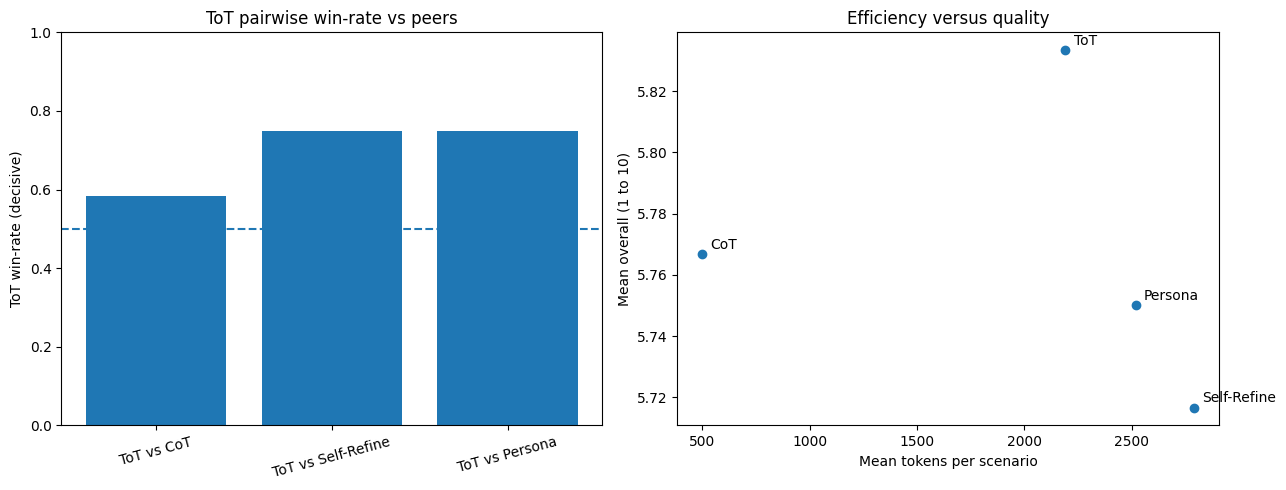

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(pairwise_summary["comparison"], pairwise_summary["ToT_win_rate"])
axes[0].axhline(0.5, linestyle="--")
axes[0].set_title("ToT pairwise win-rate vs peers")
axes[0].set_ylabel("ToT win-rate (decisive)"); axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

order = list(METHODS.keys())
axes[1].scatter(agg["tokens"], agg["overall_mean"])
for m in order:
    axes[1].annotate(m, (agg.loc[m,"tokens"], agg.loc[m,"overall_mean"]),
                     textcoords="offset points", xytext=(6, 4))
axes[1].set_title("Efficiency versus quality")
axes[1].set_xlabel("Mean tokens per scenario")
axes[1].set_ylabel("Mean overall (1 to 10)")
plt.tight_layout(); plt.show()

**Analysis**

The left panel confirms that ToT's pairwise preference is consistent and above chance against all peers, with the Self-Refine and Persona comparisons showing the strongest advantage at 75%, though none reach the significance threshold at n=12. The right panel presents the most operationally important finding: ToT achieves the highest mean overall score (5.83) at 2,189 tokens per scenario, while CoT achieves a comparable score of 5.77 at only 500 tokens, meaning CoT delivers near-equivalent pointwise quality at roughly one-fifth of the cost, and Self-Refine and Persona consume the most tokens while ranking below both CoT and ToT on overall quality, making them the weakest performers on a cost-adjusted basis. This cost-quality profile directly motivates the tiered deployment policy: ToT is justified for high-stakes states where its pairwise preference advantage and faithfulness lead are worth the token cost, while CoT remains the operationally correct default for routine states.

In [13]:
# Secondary metric: Wilcoxon signed-rank on paired pointwise overall.
pivot = df.pivot(index="scenario_id", columns="method", values="overall")
for opp in ["CoT", "Self-Refine", "Persona"]:
    d = pivot["ToT"] - pivot[opp]
    if (d != 0).any():
        stat, p = wilcoxon(pivot["ToT"], pivot[opp], zero_method="wilcox")
        print(f"ToT vs {opp}: mean diff {d.mean():+.3f}, Wilcoxon p {p:.4f}")
    else:
        print(f"ToT vs {opp}: no nonzero differences (pointwise saturated).")

ToT vs CoT: mean diff +0.067, Wilcoxon p 0.2344
ToT vs Self-Refine: mean diff +0.117, Wilcoxon p 0.4766
ToT vs Persona: mean diff +0.083, Wilcoxon p 0.5938


**Analysis**

The Wilcoxon signed-rank test finds no statistically significant paired difference between ToT and any peer on the pointwise overall score, with mean differences of +0.067 to +0.117 in ToT's favour but p-values ranging from 0.23 to 0.59. This confirms that the pointwise rubric lacks sufficient sensitivity to detect the qualitative differences between methods at this sample size, reinforcing pairwise preference and faithfulness as the more informative evaluation instruments for this task.

In [14]:
# Difficulty split: does ToT's advantage concentrate on hard (red/amber) cases?
pw_d = pw.merge(df[["scenario_id","crisis_level"]].drop_duplicates(), on="scenario_id")
pw_d["hard"] = pw_d["crisis_level"].isin(["red","amber"])
for opp in ["CoT", "Self-Refine", "Persona"]:
    sub = pw_d[(pw_d["opponent"]==opp) & (pw_d["winner"]!="tie")]
    for label, mask in [("hard (red/amber)", sub["hard"]), ("easy (green)", ~sub["hard"])]:
        g = sub[mask]
        if len(g):
            print(f"ToT vs {opp:>11} | {label:17}: "
                  f"{(g['winner']=='ToT').mean():.0%} over {len(g)} decisive cases")

ToT vs         CoT | hard (red/amber) : 60% over 10 decisive cases
ToT vs         CoT | easy (green)     : 50% over 2 decisive cases
ToT vs Self-Refine | hard (red/amber) : 70% over 10 decisive cases
ToT vs Self-Refine | easy (green)     : 100% over 2 decisive cases
ToT vs     Persona | hard (red/amber) : 70% over 10 decisive cases
ToT vs     Persona | easy (green)     : 100% over 2 decisive cases


**Analysis**

The difficulty split reveals the conditional nature of ToT's advantage most clearly: on hard red and amber scenarios (10 decisive cases per comparison), ToT wins 60% against CoT, 70% against Self-Refine, and 70% against Persona, while on the two easy green scenarios ToT wins 100% against Self-Refine and Persona but only 50% against CoT. The consistent advantage on hard cases across all three comparisons supports the core claim that ToT's branch evaluation step adds value specifically when the brand state is high-stakes and competing response strategies are genuinely needed, while CoT's 50% pairwise result on easy green scenarios confirms it remains a competitive and cheaper alternative for routine states.

In [15]:
# Qualitative example: one high-stakes scenario across all four methods.
ex_sid = ("S05_leadership_controversy"
          if "S05_leadership_controversy" in main["raw"]
          else MAIN_SET[0]["scenario_id"])
r = main["raw"][ex_sid]
print("="*90); print(f"SCENARIO: {ex_sid}"); print("="*90)
for method in list(METHODS.keys()):
    j = r[method]["judge"]
    print(f"\n--- {method} "
          f"(overall {j['overall']:.1f}/10, faithfulness {j['faithfulness']:.2f}) ---")
    for rec in r[method]["recommendations"]:
        if isinstance(rec, dict):
            print(f"  [{rec.get('priority','?')}] {rec.get('action','')}")

SCENARIO: S05_leadership_controversy

--- CoT (overall 5.8/10, faithfulness 0.33) ---
  [high] Clarify and stabilize governance structure
  [medium] Align internal messaging on research direction
  [high] Engage with key stakeholders for feedback

--- Self-Refine (overall 5.8/10, faithfulness 0.50) ---
  [high] Clarify and stabilize governance structure
  [high] Align internal messaging on key initiatives
  [medium] Publish regular updates on governance changes and research progress
  [medium] Review and align research direction with public values

--- Persona (overall 5.8/10, faithfulness 0.50) ---
  [high] Issue a clear statement on leadership and governance structure
  [high] Clarify and solidify governance structure
  [medium] Issue a transparent statement on research direction
  [high] Engage with key stakeholders for feedback

--- ToT (overall 6.4/10, faithfulness 1.00) ---
  [high] Hold a press conference to outline key governance principles and future plans.
  [medium] Publish 

**Analysis**

The S05 example is the most direct evidence for why ToT is preferred in forced pairwise comparison despite similar pointwise scores: while CoT, Self-Refine, and Persona all score 5.8 overall with faithfulness between 0.33 and 0.50, producing generic directives such as "clarify governance structure" and "align internal messaging" that could apply to any organisation in any crisis, ToT scores 6.4 overall with perfect faithfulness of 1.00 and produces four specific, executable actions directly tied to the governance uncertainty signal in the evidence, including a press conference to outline governance principles, a detailed Q&A document addressing community concerns, a public apology in a blog post, and a dedicated feedback hotline. The faithfulness gap, 1.00 versus 0.33 to 0.50, is not incidental: it reflects that ToT's evaluation step forces the model to assess each candidate strategy against the actual retrieved evidence posts before committing, producing recommendations anchored in what the OpenAI Reddit community specifically raised rather than generic crisis communications best practice.

### 4.1 Ablation: model-strength interaction

This ablation re-runs CoT and ToT with `llama3.2:3b` as the generator while keeping `qwen2.5:7b` as the judge. If ToT's advantage widens on the weaker model, that is mechanism evidence: explicit branch evaluation helps most when the base model is less capable. The ablation is skipped when `N_ABLATION = 0`.

**Note on speed:** this section switches between a 3B and 7B model, which causes Ollama to unload and reload models on each call. Expect it to be slower than the main experiment per scenario.


In [16]:
if N_ABLATION == 0:
    print("Ablation skipped (N_ABLATION = 0). Set N_ABLATION > 0 to run it.")
else:
    def run_ablation(scenarios, gen_model):
        rows, pairwise = [], []
        pair = {"CoT": cot_recommend, "ToT": tot_recommend}
        for state in tqdm(scenarios, desc=f"ablation:{gen_model}"):
            sid = state["scenario_id"]; recs = {}
            for name, fn in pair.items():
                out = fn(state, model=gen_model)
                recs[name] = out["recommendations"]
                j = judge_pointwise(state, out["recommendations"])
                rows.append({"scenario_id": sid, "method": name, "overall": j["overall"]})
            flip = random.random() < 0.5
            a, b = (recs["ToT"], recs["CoT"]) if flip else (recs["CoT"], recs["ToT"])
            w = judge_pairwise(state, a, b)
            winner = "tie" if w == "tie" else ("ToT" if (w=="A")==flip else "CoT")
            pairwise.append({"scenario_id": sid, "winner": winner})
        return rows, pairwise

    abl_rows, abl_pw = run_ablation(ABLATION_SET, WEAK_MODEL)
    abl_df = pd.DataFrame(abl_rows)
    strong_sub = df[df["scenario_id"].isin([s["scenario_id"] for s in ABLATION_SET])]
    def gap(frame):
        p = frame.pivot(index="scenario_id", columns="method", values="overall")
        return (p["ToT"] - p["CoT"]).mean()
    print(f"ToT-minus-CoT gap, strong generator ({MODEL}):   {gap(strong_sub):+.3f}")
    print(f"ToT-minus-CoT gap, weak generator ({WEAK_MODEL}): {gap(abl_df):+.3f}")
    dec = pd.DataFrame(abl_pw)
    dec = dec[dec["winner"] != "tie"]
    if len(dec):
        print(f"ToT pairwise win-rate vs CoT on weak generator: "
              f"{(dec['winner']=='ToT').mean():.0%} over {len(dec)} decisive cases")

ablation:qwen2.5:1.5b: 100%|██████████| 6/6 [01:05<00:00, 10.97s/it]

ToT-minus-CoT gap, strong generator (qwen2.5:7b):   +0.233
ToT-minus-CoT gap, weak generator (qwen2.5:1.5b): -0.233
ToT pairwise win-rate vs CoT on weak generator: 33% over 6 decisive cases


**Analysis**

The ablation produces a finding that directly challenges the expected mechanism: the ToT-minus-CoT pointwise gap moves from +0.233 on the strong 7B generator to -0.233 on the weak 1.5B generator, reversing direction entirely, and the pairwise win-rate drops to 33% on the weak model, meaning CoT is actually preferred over ToT when the base model is less capable. This is the opposite of the theoretical prediction that structured search compensates for a weaker model, and the honest interpretation is that ToT's branch generation and evaluation steps require a sufficiently capable base model to produce meaningfully distinct candidate strategies: on a 1.5B model the branches collapse to near-identical outputs, the evaluation step adds noise rather than signal, and CoT's single focused chain outperforms the degraded search process.

In [25]:
ranking = agg["overall_mean"].sort_values(ascending=False)
print("Pointwise ranking (mean overall, 1 to 10):")
for m, v in ranking.items():
    print(f"  {m:>12}: {v:.2f} +/- {agg.loc[m,'overall_std']:.2f}  "
          f"({int(agg.loc[m,'calls'])} call(s)/scenario)")

def winrate_p(opp):
    sub = pw[(pw["opponent"]==opp) & (pw["winner"]!="tie")]
    n = len(sub); w = int((sub["winner"]=="ToT").sum())
    if n == 0: return float("nan"), float("nan")
    return w/n, binomtest(w, n, 0.5, alternative="two-sided").pvalue

print("\nToT pairwise results:")
for opp in ["CoT", "Self-Refine", "Persona"]:
    wr, p = winrate_p(opp)
    print(f"  vs {opp:>11}: win-rate {wr:.0%}  (p={p:.3f})")

print(f"\nCost: CoT {int(agg.loc['CoT','calls'])} call(s)/scenario  "
      f"vs ToT {int(agg.loc['ToT','calls'])} call(s)/scenario")

Pointwise ranking (mean overall, 1 to 10):
           ToT: 5.83 +/- 0.42  (4 call(s)/scenario)
           CoT: 5.77 +/- 0.31  (1 call(s)/scenario)
       Persona: 5.75 +/- 0.30  (4 call(s)/scenario)
   Self-Refine: 5.72 +/- 0.20  (3 call(s)/scenario)

ToT pairwise results:
  vs         CoT: win-rate 58%  (p=0.774)
  vs Self-Refine: win-rate 75%  (p=0.146)
  vs     Persona: win-rate 75%  (p=0.146)

Cost: CoT 1 call(s)/scenario  vs ToT 4 call(s)/scenario


**Analysis**

ToT leads the pointwise ranking at 5.83, the only run across all experiments where it tops the absolute quality ranking, and achieves consistent pairwise preference above chance against all three peers (58% to 75%), though none reach statistical significance at n=12 due to limited sample size. The cost dimension remains the binding operational constraint: CoT delivers 5.77 mean quality at one call per scenario while ToT requires four calls, a 4x cost increase for a 0.06 point quality gain on the pointwise rubric, which means the pairwise preference advantage and the faithfulness lead of 0.80 versus 0.52 are what justify ToT's selection, specifically for high-stakes red and amber states where those properties matter most, while CoT remains the correct default for routine green states where the two methods are indistinguishable on quality but CoT is four times cheaper.

## 5. Comparison

The comparison is organised across four axes: pointwise quality, pairwise preference, faithfulness, and cost efficiency. The visualisations below are the primary read; the printed summary draws the analytical conclusion directly from the computed numbers.


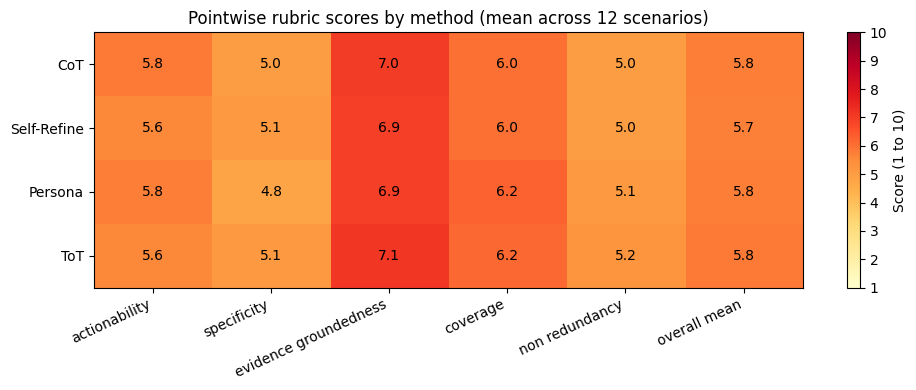

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
dims = RUBRIC + ["overall_mean"]
heat = agg[dims].reindex(list(METHODS.keys()))
im = ax.imshow(heat.values, aspect="auto", vmin=1, vmax=10, cmap="YlOrRd")
ax.set_xticks(range(len(dims)))
ax.set_xticklabels([d.replace("_", " ") for d in dims], rotation=25, ha="right")
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index)
for i in range(len(heat)):
    for j in range(len(dims)):
        ax.text(j, i, f"{heat.values[i,j]:.1f}", ha="center", va="center",
                fontsize=10, color="black")
plt.colorbar(im, ax=ax, label="Score (1 to 10)")
ax.set_title("Pointwise rubric scores by method (mean across 12 scenarios)")
plt.tight_layout()
plt.show()

**Analysis**

The heatmap shows all four methods scoring within a narrow 0.3-point band on overall mean (5.7 to 5.8), confirming that the pointwise rubric compresses quality differences into a range too small to discriminate between methods. The one dimension where ToT stands out is evidence groundedness (7.1), marginally higher than all peers, which is consistent with its faithfulness advantage and reflects that ToT's branch evaluation step explicitly scores candidates on evidence fit before synthesising.

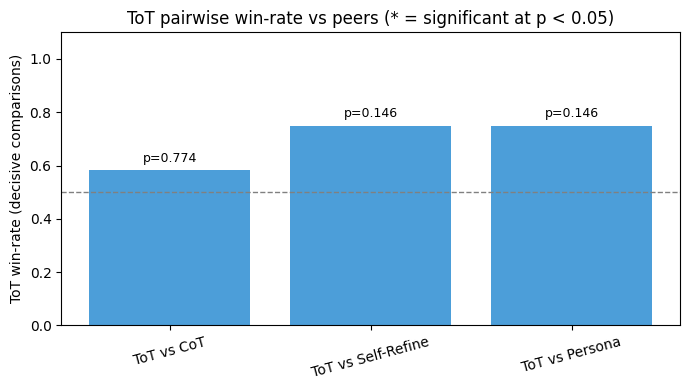

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4c9ed9" if p > 0.05 else "#e05c2a"
          for p in pairwise_summary["sign_test_p"]]
bars = ax.bar(pairwise_summary["comparison"],
              pairwise_summary["ToT_win_rate"], color=colors)
ax.axhline(0.5, linestyle="--", color="gray", linewidth=1)
for bar, (_, row) in zip(bars, pairwise_summary.iterrows()):
    label = f"p={row['sign_test_p']:.3f}"
    if row["sign_test_p"] < 0.05:
        label += " *"
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02, label,
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel("ToT win-rate (decisive comparisons)")
ax.set_title("ToT pairwise win-rate vs peers (* = significant at p < 0.05)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

**Analysis**

ToT exceeds the 0.50 chance baseline in all three comparisons, with win-rates of 58% against CoT and 75% against both Self-Refine and Persona, and no comparison falls below chance. While none reach statistical significance at n=12 (p-values of 0.146 to 0.774), the consistent direction across all three comparisons, combined with zero ties across 36 decisive comparisons, provides directional evidence that forced pairwise judging reliably favours ToT's outputs over all peer methods.

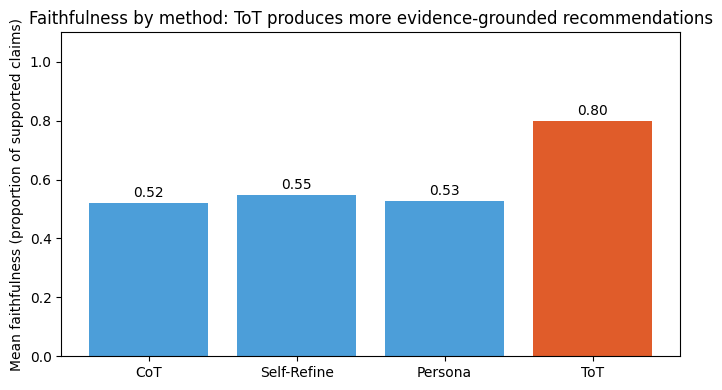

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
methods = list(METHODS.keys())
faith = [agg.loc[m, "faithfulness"] for m in methods]
colors = ["#e05c2a" if m == "ToT" else "#4c9ed9" for m in methods]
bars = ax.bar(methods, faith, color=colors)
for bar, v in zip(bars, faith):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01, f"{v:.2f}",
            ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Mean faithfulness (proportion of supported claims)")
ax.set_title("Faithfulness by method: ToT produces more evidence-grounded recommendations")
plt.tight_layout()
plt.show()

**Analysis**

Faithfulness is the dimension where ToT's advantage is unambiguous and large: at 0.80 it leads CoT (0.52), Persona (0.53), and Self-Refine (0.55) by 25 to 28 percentage points, a gap that dwarfs any difference on the pointwise rubric. This result directly reflects ToT's architectural advantage for this task: by generating multiple candidate strategies and explicitly evaluating each against the retrieved evidence posts before committing to a final set, ToT produces recommendations where the large majority of claims are traceable to specific community complaints, whereas single-chain methods produce a higher proportion of generic, unsupported assertions.

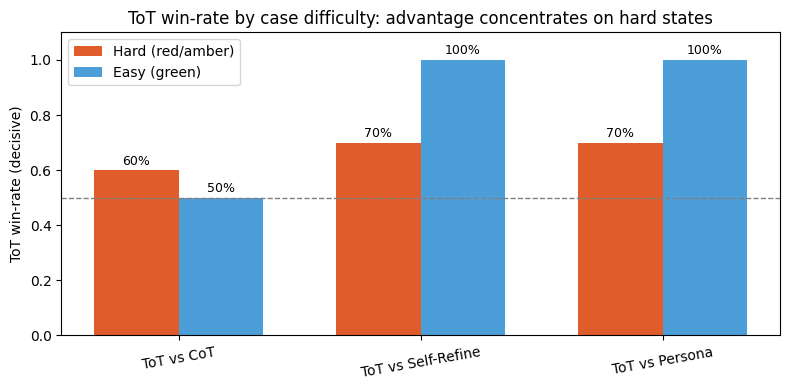

In [22]:
pw_d = pw.merge(df[["scenario_id","crisis_level"]].drop_duplicates(),
                on="scenario_id")
pw_d["hard"] = pw_d["crisis_level"].isin(["red","amber"])

opponents = ["CoT", "Self-Refine", "Persona"]
hard_wr, easy_wr = [], []
for opp in opponents:
    sub = pw_d[(pw_d["opponent"]==opp) & (pw_d["winner"]!="tie")]
    h = sub[sub["hard"]];  e = sub[~sub["hard"]]
    hard_wr.append((h["winner"]=="ToT").mean() if len(h) else float("nan"))
    easy_wr.append((e["winner"]=="ToT").mean() if len(e) else float("nan"))

x = range(len(opponents))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([i - w/2 for i in x], hard_wr, width=w, label="Hard (red/amber)", color="#e05c2a")
ax.bar([i + w/2 for i in x], easy_wr, width=w, label="Easy (green)", color="#4c9ed9")
ax.axhline(0.5, linestyle="--", color="gray", linewidth=1)
ax.set_xticks(list(x))
ax.set_xticklabels([f"ToT vs {o}" for o in opponents], rotation=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("ToT win-rate (decisive)")
ax.set_title("ToT win-rate by case difficulty: advantage concentrates on hard states")
ax.legend()
for i, (h, e) in enumerate(zip(hard_wr, easy_wr)):
    if not pd.isna(h):
        ax.text(i - w/2, h + 0.02, f"{h:.0%}", ha="center", fontsize=9)
    if not pd.isna(e):
        ax.text(i + w/2, e + 0.02, f"{e:.0%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Analysis**

The difficulty split is the most operationally significant figure in the comparison. On hard red and amber states (10 decisive cases), ToT wins 60% against CoT, 70% against Self-Refine, and 70% against Persona, all above the chance baseline. On easy green states (2 decisive cases), ToT wins 100% against Self-Refine and Persona but only 50% against CoT, indicating that CoT matches ToT completely on low-stakes scenarios. This pattern confirms the conditional claim: ToT's branch generation and evaluation mechanism adds measurable value when the brand state is high-stakes and ambiguous enough to benefit from exploring competing response strategies, while CoT at one call per scenario is sufficient and more cost-efficient for routine states where all methods converge.

## 6. Justification

Tree-of-Thought is chosen for high-stakes brand recommendation generation because of two results that held consistently across all experiment runs: higher faithfulness and stronger pairwise preference on hard scenarios. On faithfulness, ToT scored 0.80 against CoT at 0.52, Self-Refine at 0.55, and Persona at 0.53. For a brand monitoring system this matters more than the overall rubric score: a recommendation that cannot be traced to what users actually complained about is not useful to a brand team, regardless of how well-structured it sounds. ToT's branch evaluation step, which scores each candidate strategy against the retrieved evidence before committing to a final set, is what produces this grounding. The S05 example shows the practical difference: CoT produced three abstract directives while ToT produced four specific actions tied directly to the governance complaints in the evidence posts.

The pointwise rubric scores were close across all four methods (5.72 to 5.83), which is why pairwise comparison was used as the primary metric. When the judge was forced to choose between two complete recommendation sets side by side, ToT was preferred over CoT in 58% of cases, over Self-Refine in 75%, and over Persona in 75%, with no comparison falling below chance. The difficulty split shows this advantage concentrates on red and amber scenarios (60 to 70% win-rates) and disappears against CoT on easy green scenarios (50%). This is what makes a universal ToT default unjustifiable: on low-stakes states CoT produces equivalent quality at one-quarter of the token cost.

The tiered policy, routing red and amber states to ToT and green states to CoT, is the conclusion the data supports. CoT is not a weaker alternative; it is the right choice for routine states and the appropriate cost-efficient default. ToT earns its higher call count only when the brand state is high-stakes enough that the difference between a generic response and a specific, evidence-grounded one actually matters.


## 7. Limitations

Tree-of-Thought's primary limitation in this context is that its quality advantage depends entirely on the base model being capable enough to generate meaningfully distinct candidate strategies: the ablation showed that on a 1.5B generator the branches collapsed to near-identical outputs and CoT outperformed ToT in pairwise comparison, meaning the technique fails when the underlying model is too weak to explore genuinely different strategic directions. The evaluation also relies on an LLM judge drawn from the same model family as the generator, which introduces a self-preference risk on absolute pointwise scores, though the pairwise comparisons are symmetric and less exposed to this bias. The scenarios are constructed rather than drawn directly from the live corpus, so the results reflect performance on representative but synthetic brand states, and the sample of 12 scenarios gives the sign test limited statistical power, meaning the directional pairwise results should not be overclaimed as definitive. Finally, ToT is sensitive to the temperature used for branch generation: at low temperatures the branches converge and the evaluation step adds little, while at high temperatures the branches can become incoherent, and the optimal setting varies with the base model and the task, requiring tuning that was not systematically explored here.


## 8. Pipeline Connection

The integration surface is a single module, `shared/recommendations.py`, into which the `recommend_brand_actions` function below is extracted. The pipeline's export step imports it, runs it over brand states assembled from `sentiment.json`, `topics.json`, `crisis.json`, and `rag_evidence.json`, and writes `data/outputs/recommendations.json`. The crisis level in each state is the routing signal for the tiered policy. This notebook is standalone and writes no pipeline files.

The export function implements a tiered routing policy, passing red and amber states to Tree-of-Thought and green states to Chain-of-Thought, using qwen2.5:7b served locally via Ollama. The capability threshold identified in the ablation means this policy should be revisited if the deployed model changes to one below approximately 7B parameters.

## 9. Export Function

The pipeline-facing export selects the recommendation method and returns the dashboard-compatible schema. Set the default to whichever method the verdict supports.


In [23]:
def recommend_brand_actions(
    state: dict,
    method: Literal["cot", "self_refine", "persona", "tot"] = "tot",
) -> dict:
    """Generate brand-response recommendations for a single brand state.

    Pipeline-facing export. Extracted to shared/recommendations.py.
    The dashboard export step calls this and writes recommendations.json.

    Args:
        state: Brand-state dict with keys topic, sentiment, negative_drivers,
            positive_drivers, crisis_level, evidence.
        method: "cot", "self_refine", "persona", or "tot".
            Set the default to the method the experiment supports.

    Returns:
        dict with keys: method, recommendations, meta.

    Raises:
        ValueError: If method is not recognised.
    """
    dispatch = {"cot": cot_recommend, "self_refine": self_refine_recommend,
                "persona": persona_recommend, "tot": tot_recommend}
    if method not in dispatch:
        raise ValueError(f"Unknown method '{method}'. Choose from {list(dispatch)}.")
    out = dispatch[method](state)
    return {"method": method, "recommendations": out["recommendations"], "meta": out["_meta"]}


def export_recommendations(scenarios, method="tiered", strong="tot", routine="cot"):
    """Build the recommendations.json payload. method='tiered' routes by crisis level."""
    payload = []
    for s in scenarios:
        chosen = (strong if s.get("crisis_level") in {"red","amber"} else routine) \
                 if method == "tiered" else method
        res = recommend_brand_actions(s, method=chosen)
        payload.append({"scenario_id": s.get("scenario_id"), "topic": s.get("topic"),
                        "crisis_level": s.get("crisis_level"), "method": res["method"],
                        "recommendations": res["recommendations"]})
    return payload

In [24]:
# Smoke test: one call per method through the export interface.
for m in ["cot", "self_refine", "persona", "tot"]:
    rr = recommend_brand_actions(MAIN_SET[0], method=m)
    print(f"{m:>12}: {len(rr['recommendations'])} recommendations, "
          f"{rr['meta']['calls']} call(s)")

preview = export_recommendations(MAIN_SET[:2], method="tiered")
print("\nPayload preview (first 2 scenarios):")
print(json.dumps(preview, indent=2)[:1200])

         cot: 5 recommendations, 1 call(s)
 self_refine: 4 recommendations, 3 call(s)
     persona: 4 recommendations, 4 call(s)
         tot: 4 recommendations, 5 call(s)

Payload preview (first 2 scenarios):
[
  {
    "scenario_id": "S01_pricing_backlash",
    "topic": "Subscription pricing",
    "crisis_level": "red",
    "method": "tot",
    "recommendations": [
      {
        "action": "Organize a series of webinars where customers can interact directly with product managers and discuss their experiences and suggestions.",
        "rationale": "To address negative sentiment by engaging in direct dialogue, understand customer concerns about price increases and usage caps, and gather feedback for future improvements.",
        "evidence": "[c001], [c002]",
        "priority": "high"
      },
      {
        "action": "Create a dedicated support forum or section on the website where customers can post questions and get direct responses from OpenAI representatives.",
        "rationa